# Projeto de Cresciemnto

In [7]:
#Trocar o caminho do arquivo para o caminho do seu computador
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt


print(os.getcwd())

c:\Users\jessi\Pos FISP\Desafios Pos\Fiap_projeto1


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

pasta = r"C:\Users\jessi\Pos FISP\Desafios Pos\Fiap_projeto1\dados.db"

orders = pd.read_csv(
    f"{pasta}/olist_orders_dataset.csv",
    usecols=["order_id", "order_purchase_timestamp", "customer_id"],
    parse_dates=["order_purchase_timestamp"]
)

orders["ano"] = orders["order_purchase_timestamp"].dt.year

order_items = pd.read_csv(
    f"{pasta}/olist_order_items_dataset.csv",
    usecols=["order_id", "product_id", "price"]
)

products = pd.read_csv(
    f"{pasta}/olist_products_dataset.csv",
    usecols=["product_id", "product_category_name", "product_name_lenght"]
)

products_moveis = products.loc[
    products["product_category_name"] == "moveis_decoracao",
    ["product_id", "product_name_lenght"]
]

payments = pd.read_csv(
    f"{pasta}/olist_order_payments_dataset.csv",
    usecols=["order_id", "payment_value"]
)

payments_agg = (
    payments
    .groupby("order_id", as_index=False)
    .agg(payment_value=("payment_value", "sum"))
)

customers = pd.read_csv(
    f"{pasta}/olist_customers_dataset.csv",
    usecols=["customer_id", "customer_city", "customer_state"]
)

df = (
    order_items
    .merge(products_moveis, on="product_id", how="inner")
    .merge(orders, on="order_id", how="inner")
    .merge(customers, on="customer_id", how="inner")
    .merge(payments_agg, on="order_id", how="inner")
)

resultado = (
    df.groupby([
        "ano",
        "customer_city",
        "customer_state",
        "product_name_lenght"
    ])
    .agg(
        pedidos=("order_id", "nunique"),
        itens=("order_id", "size"),
        faturamento=("price", "sum")
    )
    .reset_index()
    .sort_values(["ano", "itens"], ascending=[True, False])
)

print(resultado)

       ano   customer_city customer_state  product_name_lenght  pedidos  \
6     2016  belo horizonte             MG                 64.0        1   
23    2016        curitiba             PR                 56.0        1   
36    2016  novo progresso             PA                 59.0        1   
9     2016        brasilia             DF                 52.0        1   
20    2016   cidade gaucha             PR                 54.0        1   
...    ...             ...            ...                  ...      ...   
4284  2018     votuporanga             SP                 53.0        1   
4285  2018     votuporanga             SP                 60.0        1   
4287  2018  wenceslau braz             PR                 58.0        1   
4288  2018           xaxim             SC                 45.0        1   
4289  2018           xaxim             SC                 57.0        1   

      itens  faturamento  
6         3         86.7  
23        3        119.7  
36        3       

C:\Users\jessi\AppData\Local\Temp\ipykernel_4264\2267869000.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


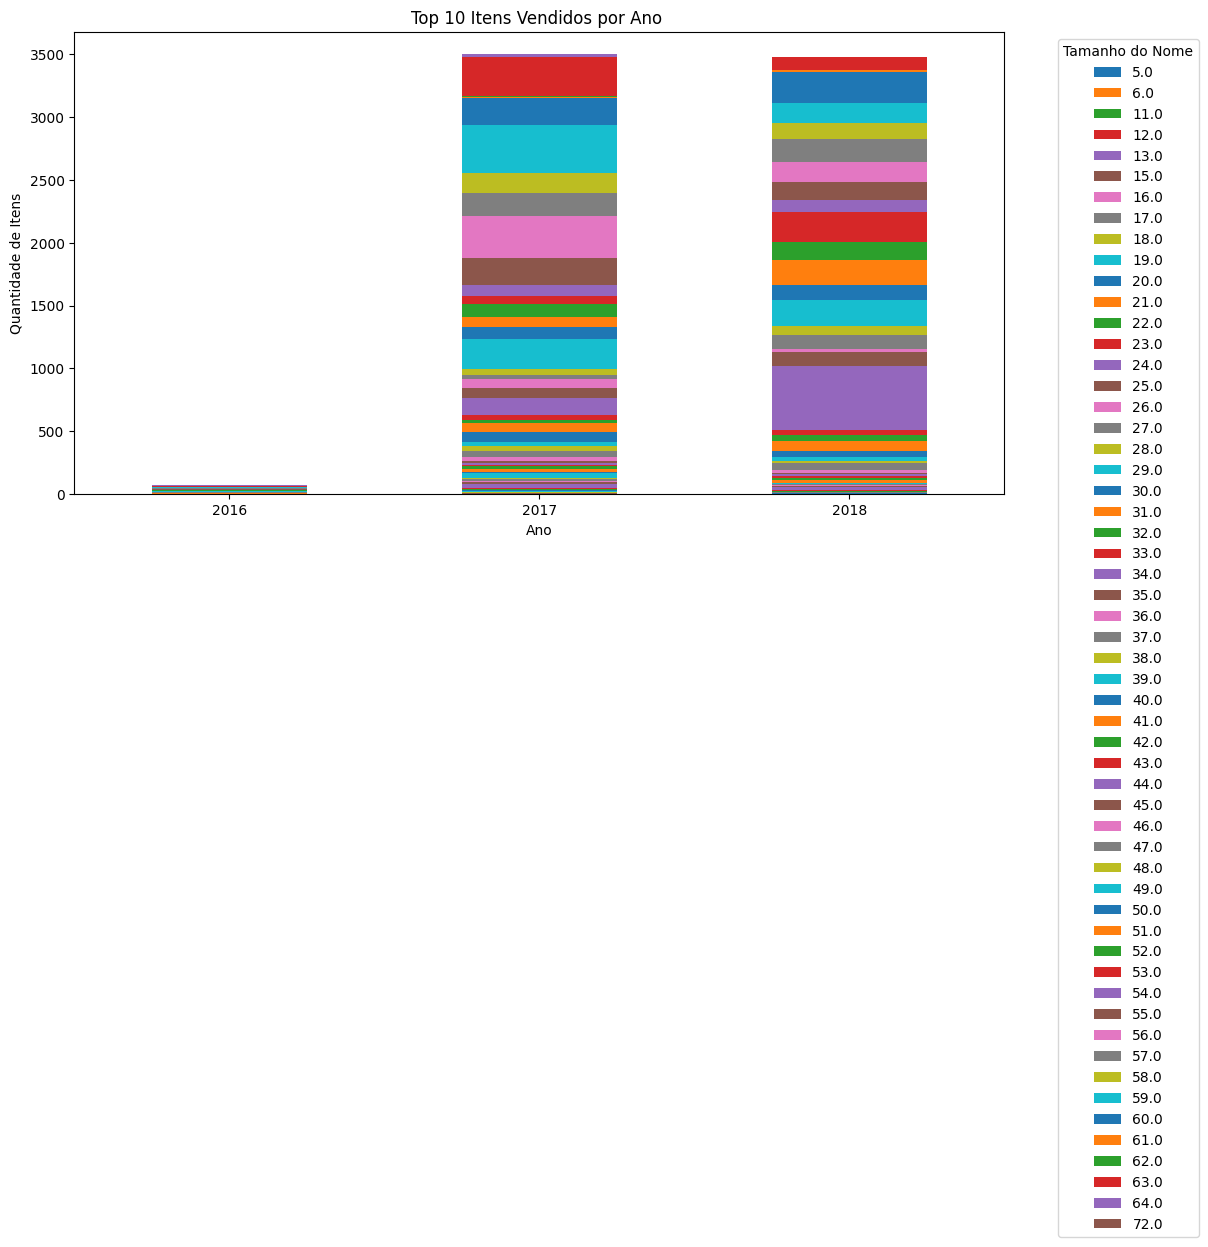

In [44]:

# Grafico pegando somente o top 10 de cada ano (QUANTIDADE DE ITENS)

top10 = (
    resultado
    .sort_values(["ano", "itens"], ascending=[True, False])
    .groupby(["ano", "customer_state", "customer_city"])
    .head(10)
)

pivot = top10.pivot_table(
    index="ano",
    columns="product_name_lenght",
    values="itens",
    aggfunc="sum"
).fillna(0)

# GRÁFICO EMPILHADO

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Top 10 Itens Vendidos por Ano ")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Itens")

plt.xticks(rotation=0)

plt.legend(
    title="Tamanho do Nome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

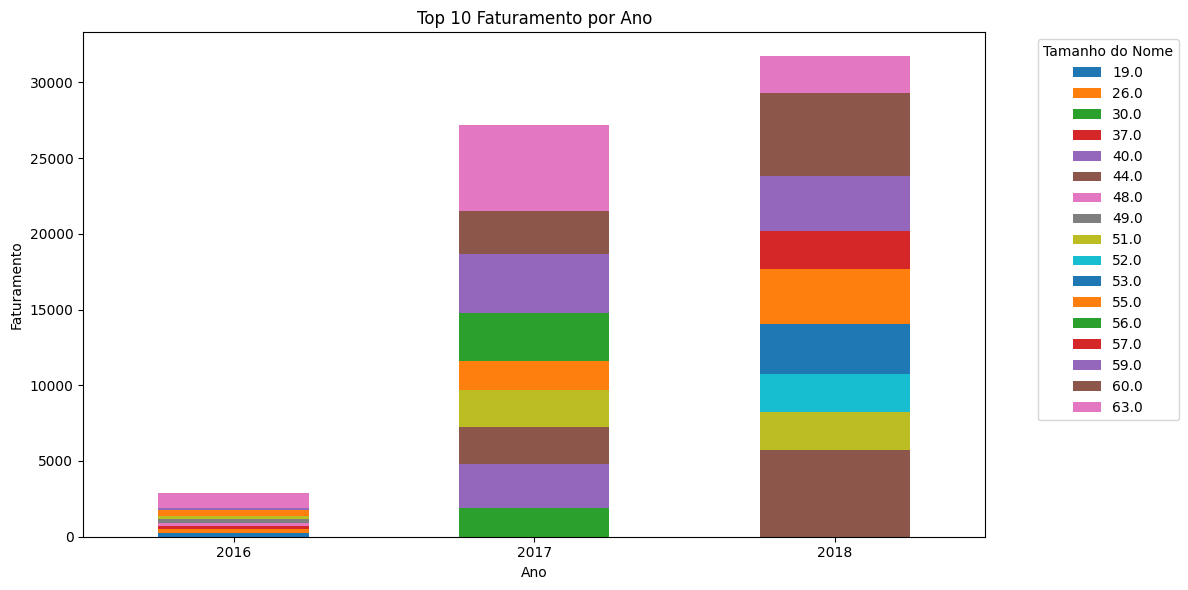

In [45]:
# Grafico pegando somente o top 10 de cada ano (por faturamento)

top10 = (
    resultado
    .reset_index()
    .sort_values(["ano", "faturamento"], ascending=[True, False])
    .groupby("ano")
    .head(10)
)

pivot = top10.pivot_table(
    index="ano",
    columns="product_name_lenght",
    values="faturamento",
    aggfunc="sum"
).fillna(0)

# GRÁFICO EMPILHADO

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Top 10 Faturamento por Ano")
plt.xlabel("Ano")
plt.ylabel("Faturamento")

plt.xticks(rotation=0)

plt.legend(
    title="Tamanho do Nome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

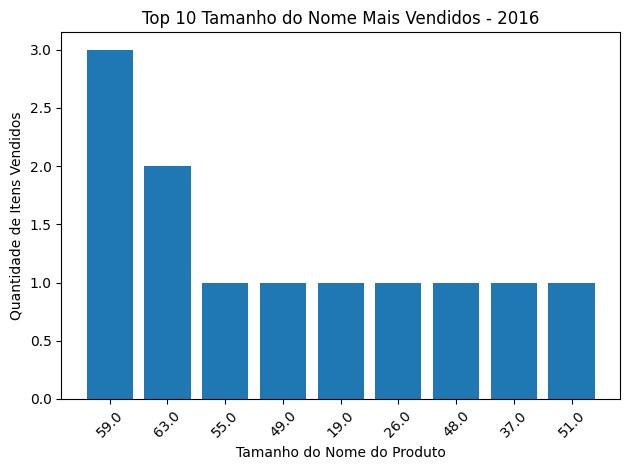

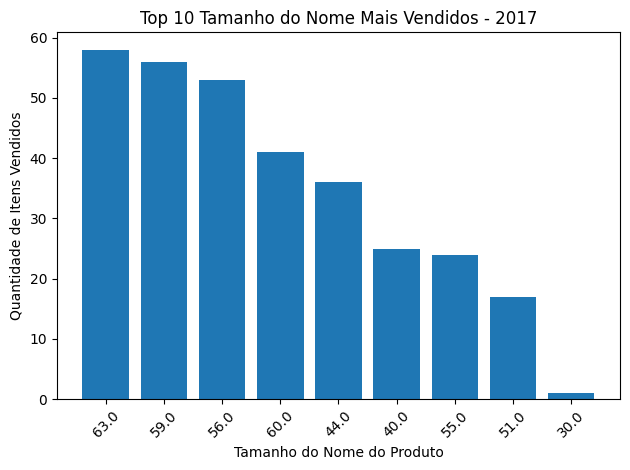

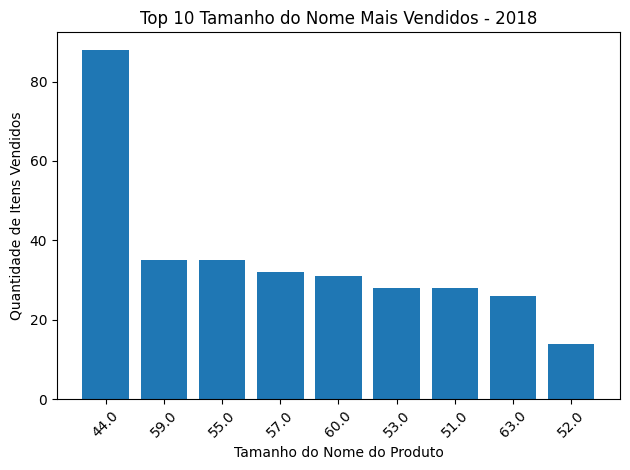

In [46]:
# Grafico de como foi de cada ano (QUANTIDADE DE ITENS)
top10 = top10.sort_values(["ano", "itens"], ascending=[True, False])

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["itens"]
    )
    
    plt.title(f"Top 10 Tamanho do Nome Mais Vendidos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Quantidade de Itens Vendidos")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

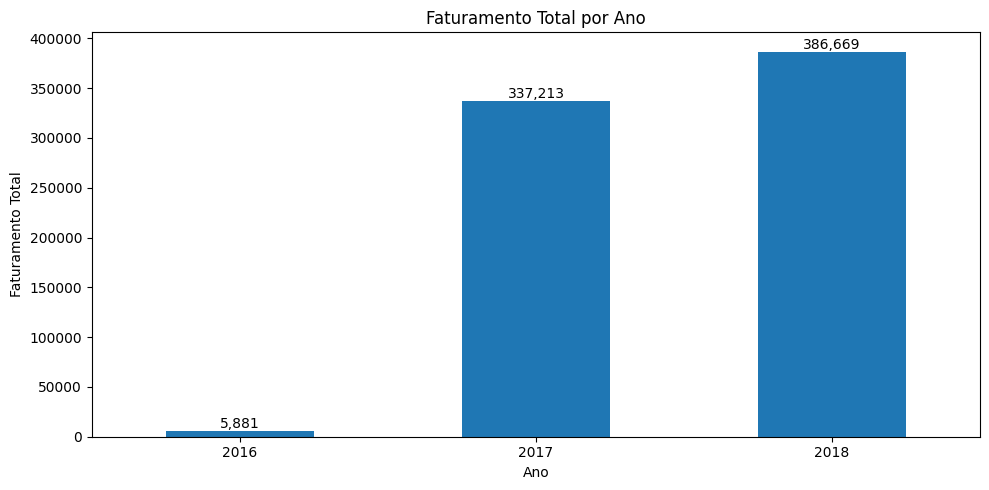

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = resultado.reset_index()

faturamento_ano = (
    df.groupby("ano")["faturamento"]
    .sum()
    .sort_index()
)

ax = faturamento_ano.plot(
    kind="bar",
    figsize=(10,5)
)

# valores em cima das barras (opcional mas recomendado)
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Faturamento Total por Ano")
plt.xlabel("Ano")
plt.ylabel("Faturamento Total")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

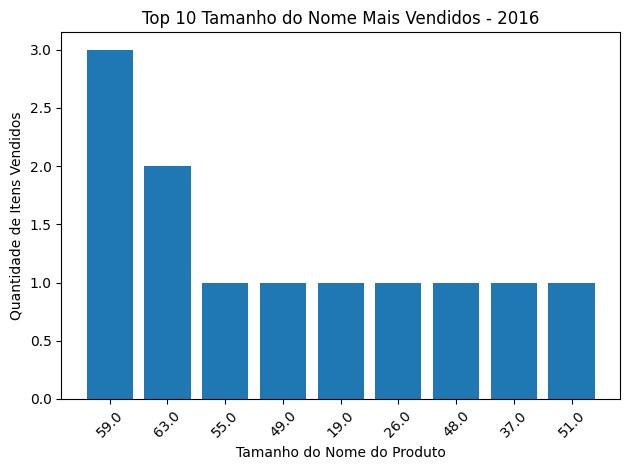

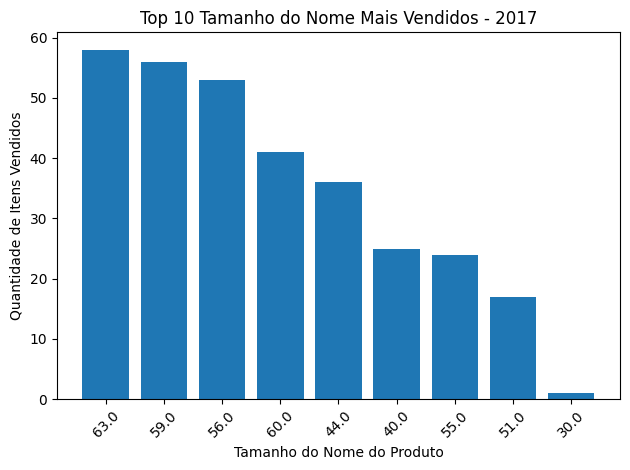

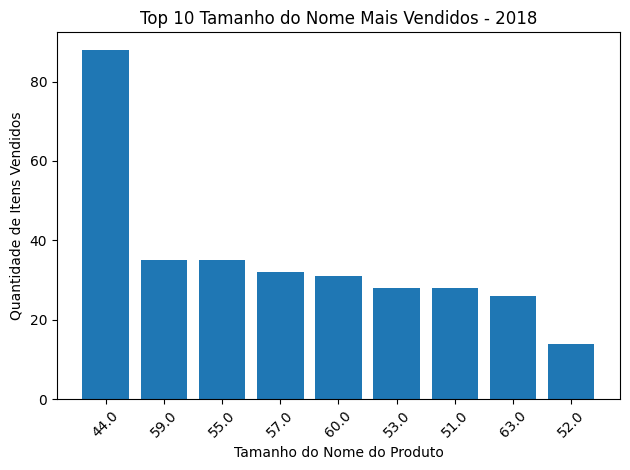

In [48]:

# Grafico de como foi de cada ano (QUANTIDADE DE ITENS)
top10 = top10.sort_values(["ano", "itens"], ascending=[True, False])

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["itens"]
    )
    
    plt.title(f"Top 10 Tamanho do Nome Mais Vendidos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Quantidade de Itens Vendidos")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

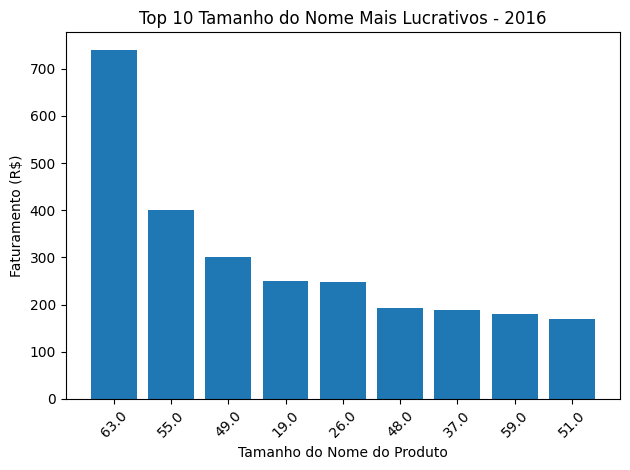

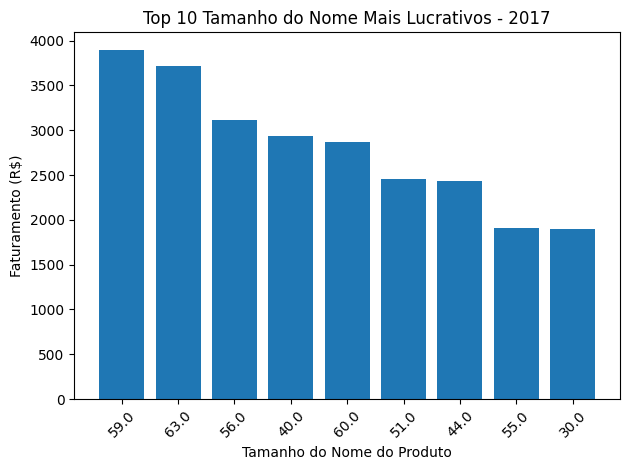

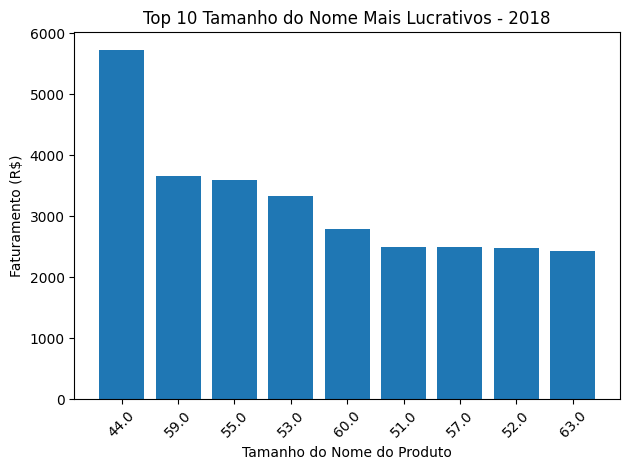

In [49]:
# Ordenar por ano e faturamento
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])

# Criar gráfico por ano
for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["faturamento"]
    )
    
    plt.title(f"Top 10 Tamanho do Nome Mais Lucrativos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

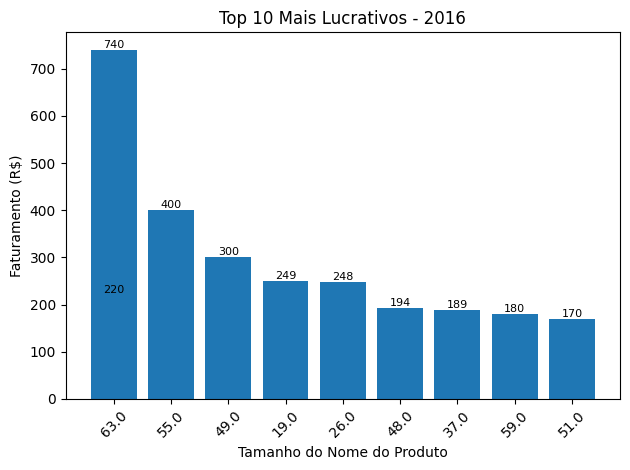

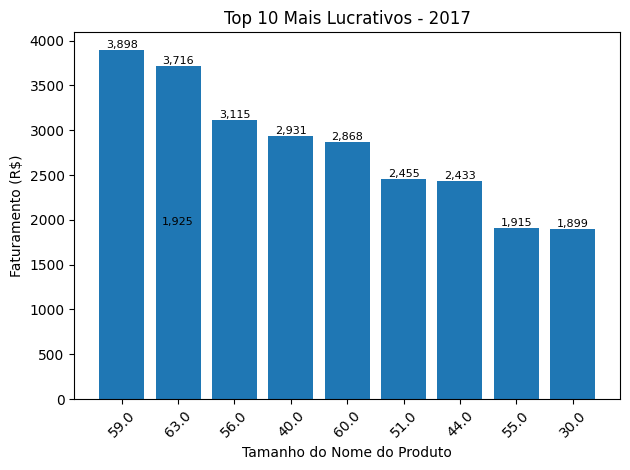

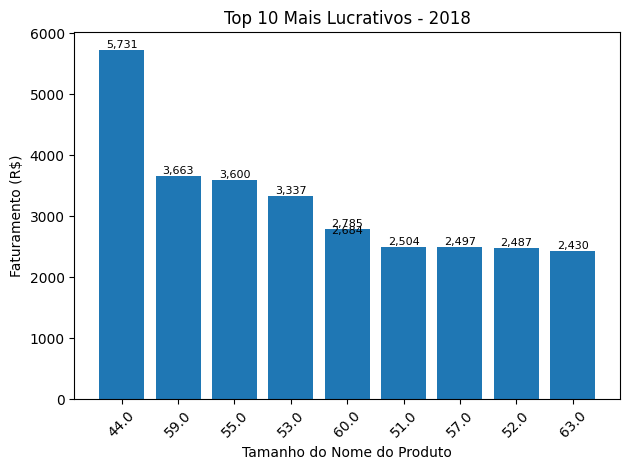

In [50]:
# Ordenar por ano e faturamento
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["faturamento"]
    )
    
    total_ano = grupo["faturamento"].sum()
    
    plt.title(f"Top 10 Mais Lucrativos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    # mostrar valor em cima das barras
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:,.0f}",
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    plt.tight_layout()
    plt.show()

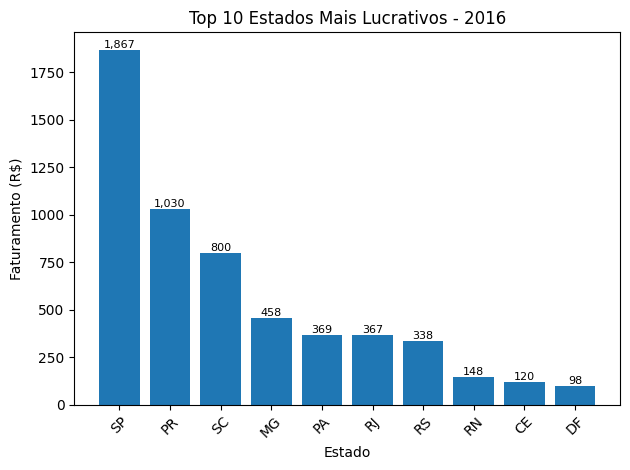

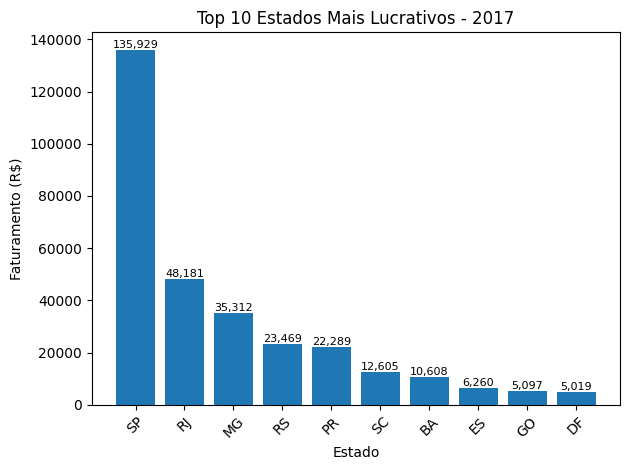

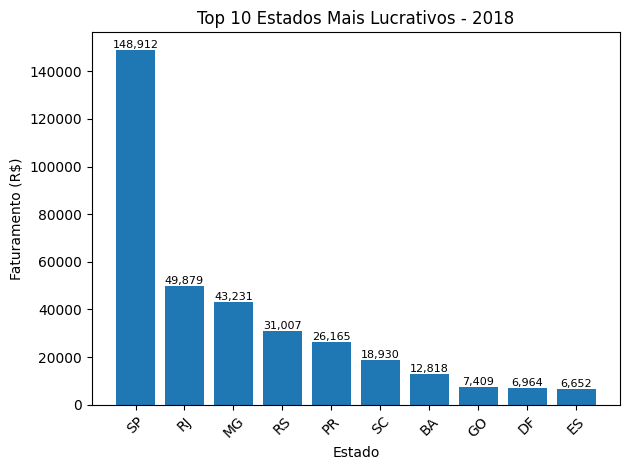

In [51]:
# 1. Consolidar corretamente antes do gráfico
top10 = (
    resultado
    .groupby(["ano", "customer_state"])
    .agg(faturamento=("faturamento", "sum"))
    .reset_index()
)

# 2. Ordenar e pegar TOP 10 por ano
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])
top10 = top10.groupby("ano").head(10)


# 3. Plot
for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["customer_state"].astype(str),
        grupo["faturamento"]
    )
    
    total_ano = grupo["faturamento"].sum()
    
    plt.title(f"Top 10 Estados Mais Lucrativos - {ano}")
    plt.xlabel("Estado")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:,.0f}",
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    plt.tight_layout()
    plt.show()

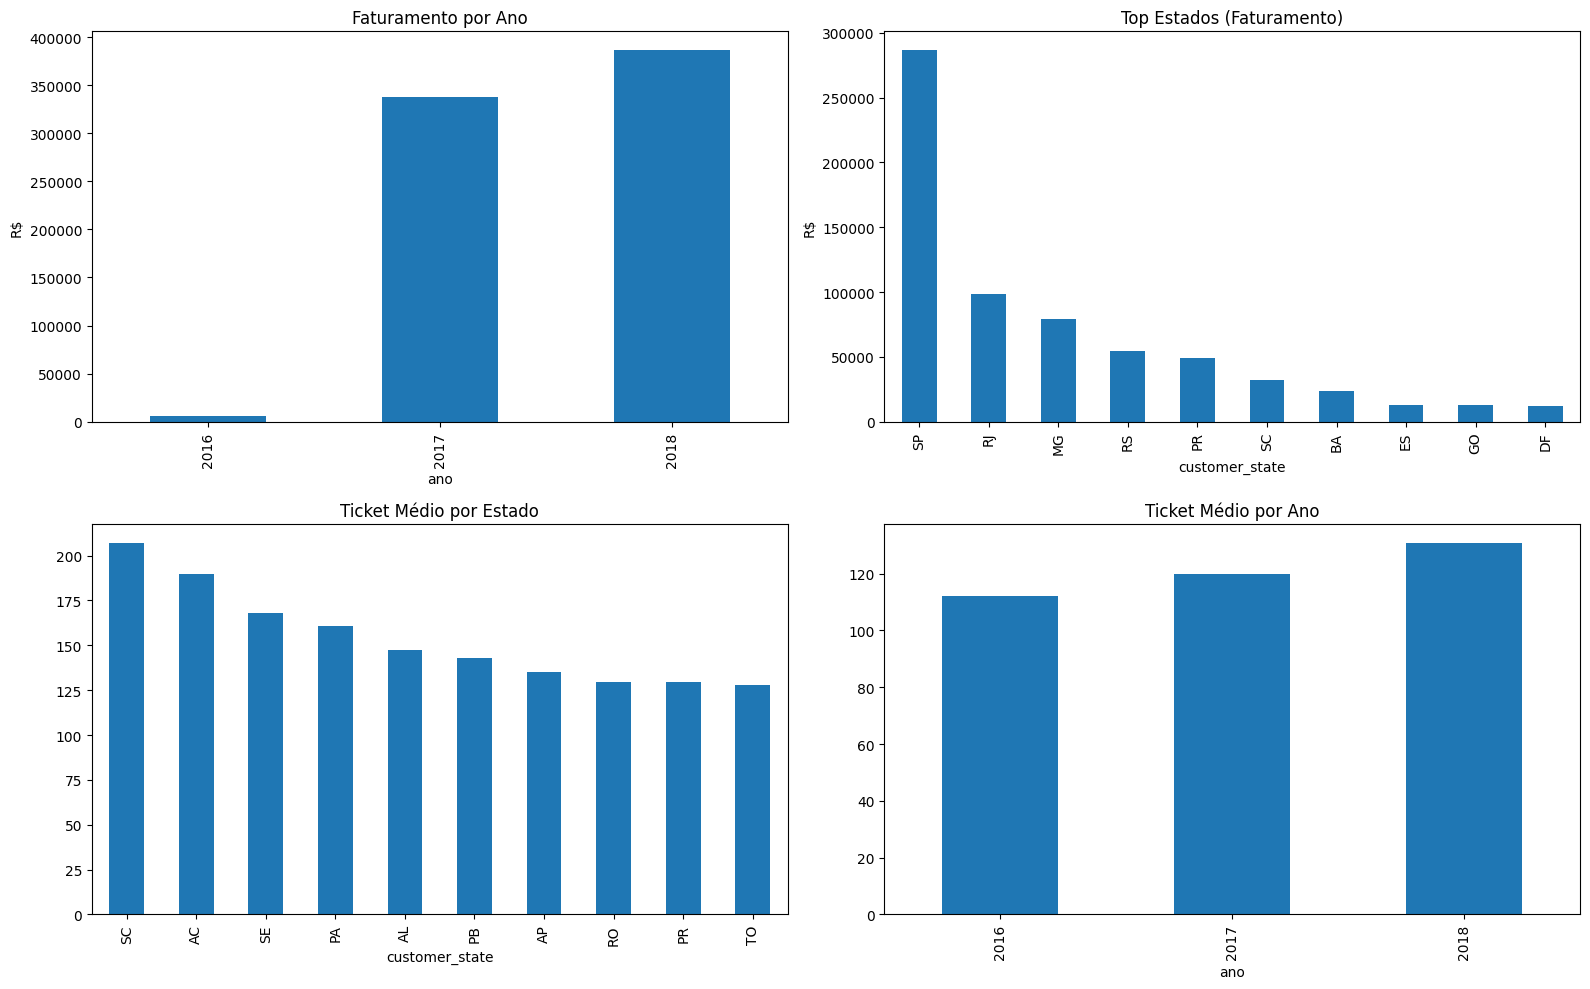

In [59]:
import matplotlib.pyplot as plt

# =========================
# 1. FATURAMENTO POR ANO
# =========================
faturamento_ano = df.groupby("ano")["faturamento"].sum().sort_index()

# =========================
# 2. TOP ESTADOS
# =========================
top_estados = (
    df.groupby("customer_state")["faturamento"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# =========================
# 3. TICKET MÉDIO
# =========================
df["ticket_medio"] = df["faturamento"] / df["pedidos"]

ticket_estado = (
    df.groupby(["ano", "customer_state"])
    .agg(
        faturamento=("faturamento", "sum"),
        pedidos=("pedidos", "sum")
    )
    .reset_index()
)

ticket_estado["ticket_medio"] = (
    ticket_estado["faturamento"] / ticket_estado["pedidos"]
)

# =========================
# 📊 VISUALIZAÇÃO
# =========================
fig, axs = plt.subplots(2, 2, figsize=(16,10))

# ---- Faturamento por ano ----
faturamento_ano.plot(kind="bar", ax=axs[0,0])
axs[0,0].set_title("Faturamento por Ano")
axs[0,0].set_ylabel("R$")

# ---- Top estados ----
top_estados.plot(kind="bar", ax=axs[0,1])
axs[0,1].set_title("Top Estados (Faturamento)")
axs[0,1].set_ylabel("R$")

# ---- Ticket médio por estado ----
ticket_estado.groupby("customer_state")["ticket_medio"].mean() \
    .sort_values(ascending=False).head(10) \
    .plot(kind="bar", ax=axs[1,0])

axs[1,0].set_title("Ticket Médio por Estado")

# ---- Ticket médio por ano ----
ticket_estado.groupby("ano")["ticket_medio"].mean() \
    .plot(kind="bar", ax=axs[1,1])

axs[1,1].set_title("Ticket Médio por Ano")

plt.tight_layout()
plt.show()

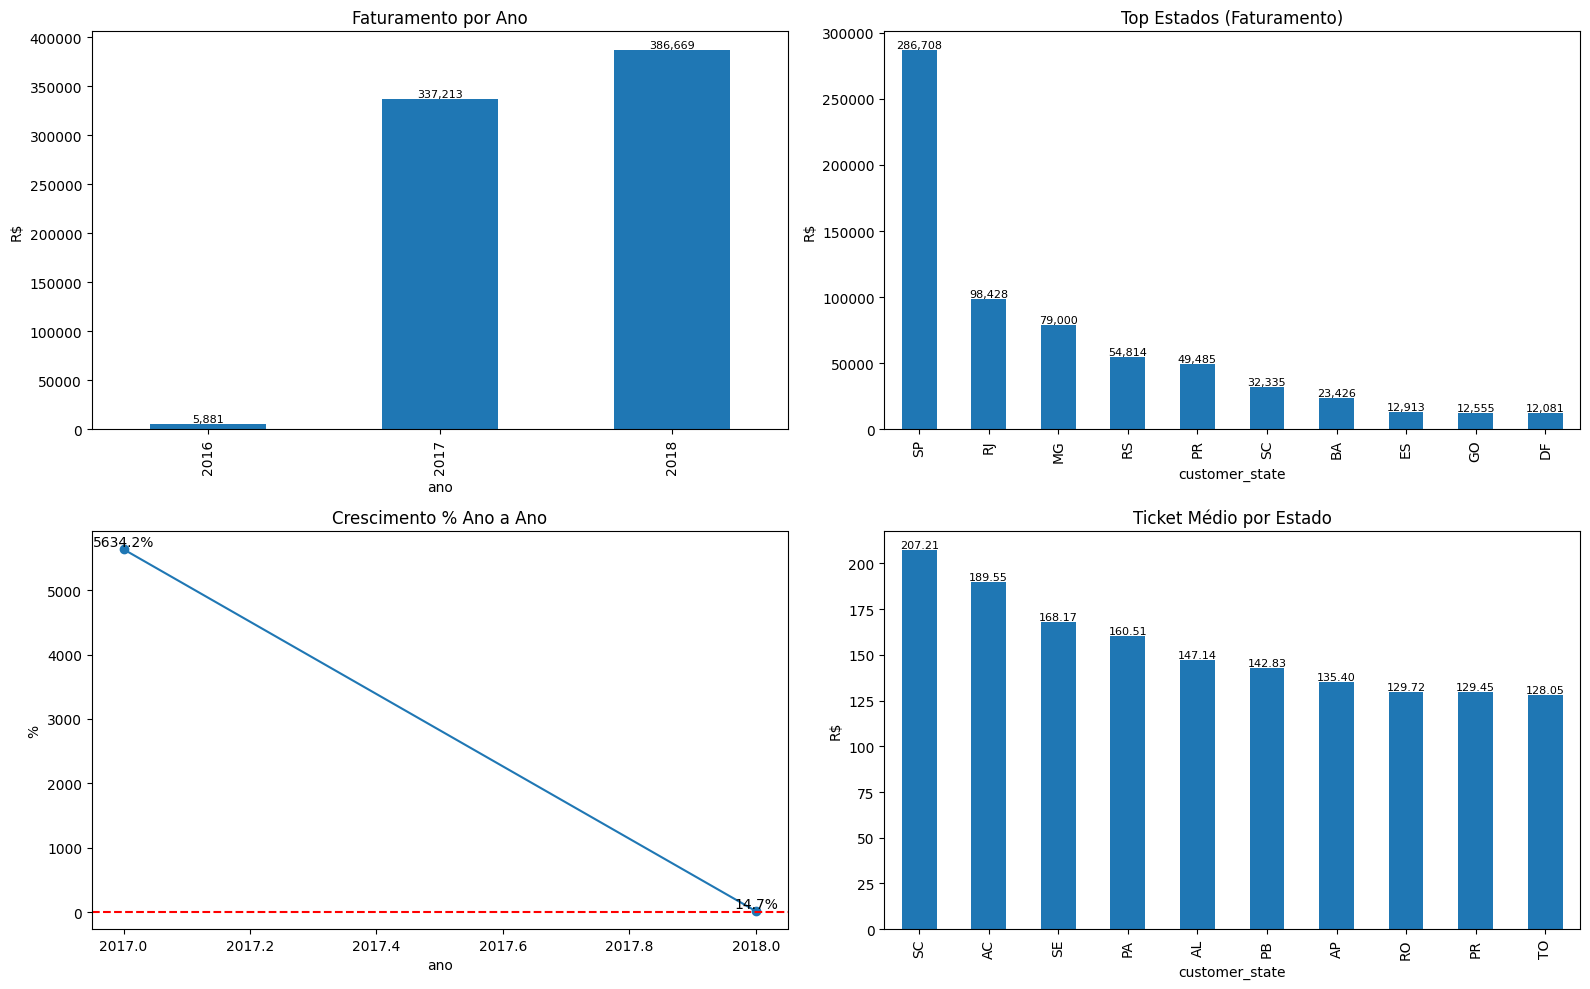

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FUNÇÃO DE LABEL
# =========================
def add_labels(ax, formato="int"):
    for p in ax.patches:
        if formato == "float":
            valor = f'{p.get_height():.2f}'
        else:
            valor = f'{p.get_height():,.0f}'

        ax.annotate(
            valor,
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=8
        )

# =========================
# BASES PRINCIPAIS
# =========================
faturamento_ano = df.groupby("ano")["faturamento"].sum().sort_index()

top_estados = (
    df.groupby("customer_state")["faturamento"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Ticket médio base
df["ticket_medio"] = df["faturamento"] / df["pedidos"]

ticket_estado = (
    df.groupby(["ano", "customer_state"])
    .agg(
        faturamento=("faturamento", "sum"),
        pedidos=("pedidos", "sum")
    )
    .reset_index()
)

ticket_estado["ticket_medio"] = (
    ticket_estado["faturamento"] / ticket_estado["pedidos"]
)

# Crescimento ano a ano
crescimento_ano = faturamento_ano.pct_change() * 100

# =========================
# DASHBOARD
# =========================
fig, axs = plt.subplots(2, 2, figsize=(16,10))

# ---- 1. Faturamento por ano ----
faturamento_ano.plot(kind="bar", ax=axs[0,0])
axs[0,0].set_title("Faturamento por Ano")
axs[0,0].set_ylabel("R$")
add_labels(axs[0,0], "int")

# ---- 2. Top estados ----
top_estados.plot(kind="bar", ax=axs[0,1])
axs[0,1].set_title("Top Estados (Faturamento)")
axs[0,1].set_ylabel("R$")
add_labels(axs[0,1], "int")

# ---- 3. Crescimento % ano a ano ----
crescimento_ano.plot(kind="line", marker="o", ax=axs[1,0])
axs[1,0].set_title("Crescimento % Ano a Ano")
axs[1,0].set_ylabel("%")
axs[1,0].axhline(0, color="red", linestyle="--")

for x, y in zip(crescimento_ano.index, crescimento_ano.values):
    if pd.notna(y):
        axs[1,0].text(x, y, f"{y:.1f}%", ha='center', va='bottom')

# ---- 4. Ticket médio por estado ----
ticket_estado.groupby("customer_state")["ticket_medio"].mean() \
    .sort_values(ascending=False).head(10) \
    .plot(kind="bar", ax=axs[1,1])

axs[1,1].set_title("Ticket Médio por Estado")
axs[1,1].set_ylabel("R$")
add_labels(axs[1,1], "float")

plt.tight_layout()
plt.show()

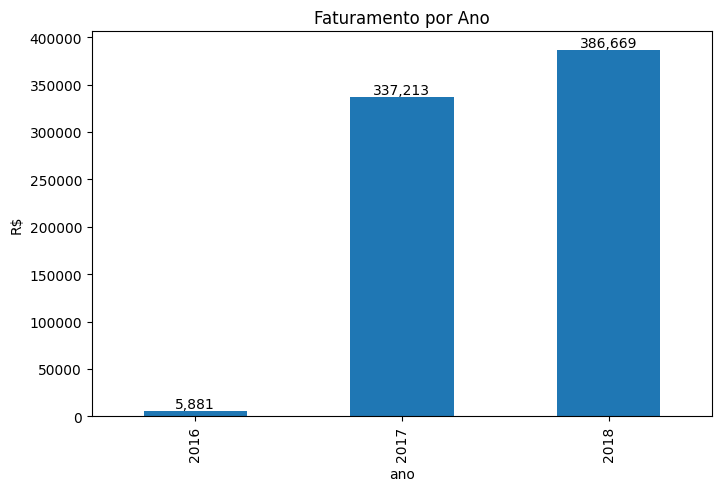

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

faturamento_ano.plot(kind="bar")

plt.title("Faturamento por Ano")
plt.ylabel("R$")

for i, v in enumerate(faturamento_ano.values):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.show()

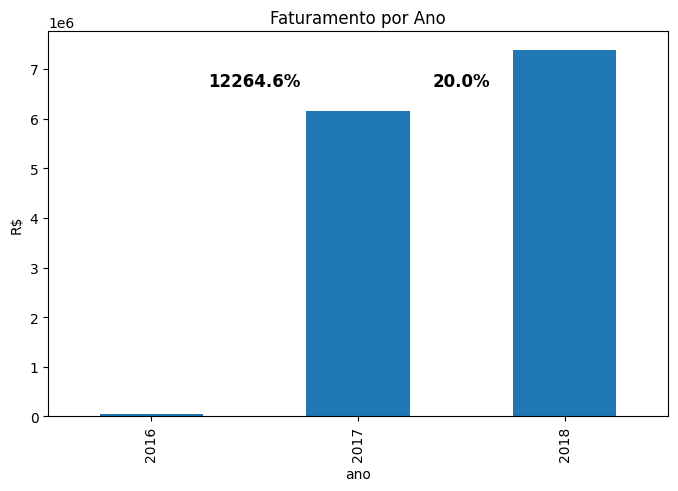

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# gráfico
faturamento_ano.plot(kind="bar")

plt.title("Faturamento por Ano")
plt.ylabel("R$")

# =========================
# CRESCIMENTO %
# =========================
valores = faturamento_ano.values

crescimento = [None]
for i in range(1, len(valores)):
    crescimento.append((valores[i] - valores[i-1]) / valores[i-1] * 100)

# mostrar apenas %
for i in range(1, len(valores)):
    x = (i + (i-1)) / 2
    y = max(valores) * 0.9

    plt.text(
        x, y,
        f"{crescimento[i]:.1f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.show()

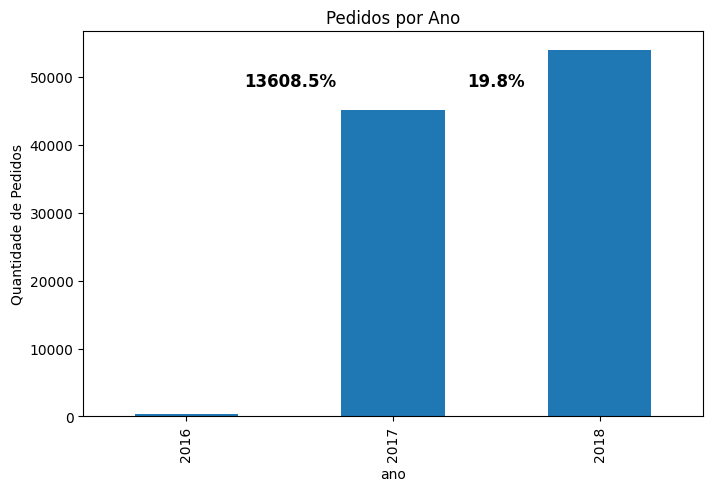

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# =========================
# PEDIDOS POR ANO
# =========================

pedidos_ano = orders.groupby("ano")["order_id"].count().sort_index()

pedidos_ano.plot(kind="bar")

plt.title("Pedidos por Ano")
plt.ylabel("Quantidade de Pedidos")

# =========================
# CRESCIMENTO %
# =========================

valores = pedidos_ano.values

crescimento = [None]
for i in range(1, len(valores)):
    crescimento.append((valores[i] - valores[i-1]) / valores[i-1] * 100)

# mostrar apenas %
for i in range(1, len(valores)):
    x = (i + (i-1)) / 2
    y = max(valores) * 0.9

    plt.text(
        x, y,
        f"{crescimento[i]:.1f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.show()

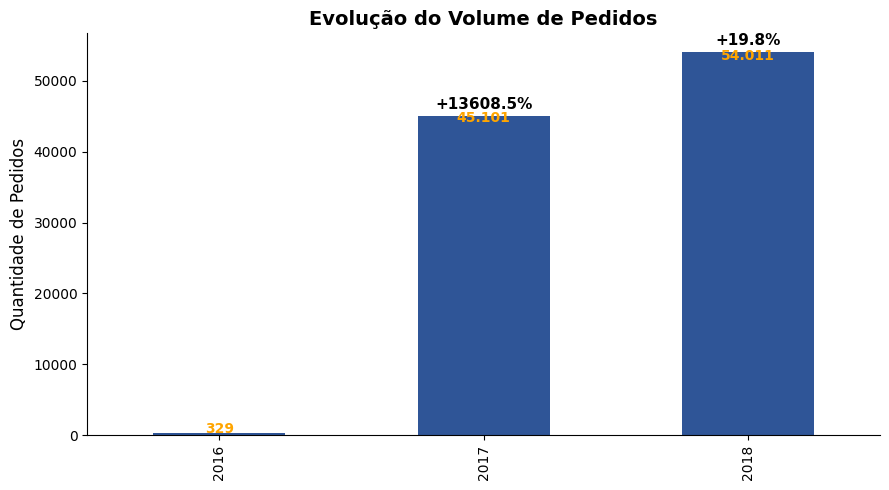

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

# =========================
# PEDIDOS POR ANO
# =========================
pedidos_ano = orders.groupby("ano")["order_id"].count().sort_index()

ax = pedidos_ano.plot(
    kind="bar",
    color="#2F5597"
)

plt.title("Evolução do Volume de Pedidos", fontsize=14, fontweight="bold")
plt.ylabel("Quantidade de Pedidos", fontsize=12)
plt.xlabel("")

# remover bordas (visual mais executivo)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =========================
# CRESCIMENTO %
# =========================
valores = pedidos_ano.values

crescimento = [None]
for i in range(1, len(valores)):
    crescimento.append(((valores[i] - valores[i-1]) / valores[i-1]) * 100)

# posicionamento mais limpo (acima das barras)
for i in range(1, len(valores)):
    plt.text(
        i,
        valores[i] * 1.02,
        f"+{crescimento[i]:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# valores em cima das barras
for i, v in enumerate(valores):
    plt.text(
        i,
        v * 0.98,
        f"{v:,}".replace(",", "."),
        ha="center",
        fontsize=10,
        color="ORANGE",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

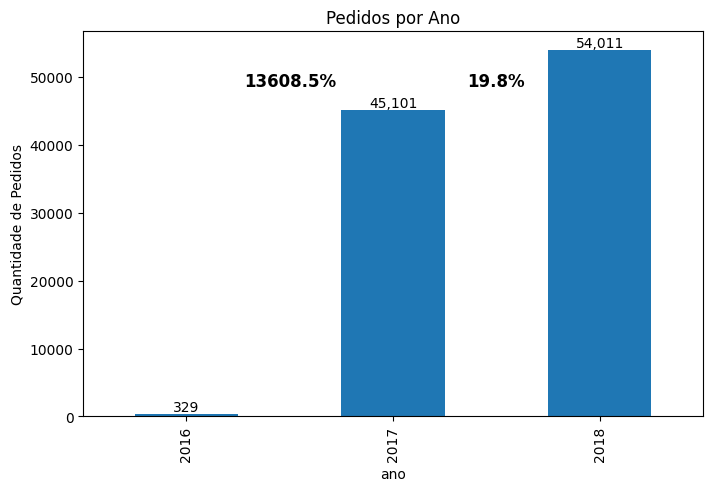

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# =========================
# PEDIDOS POR ANO
# =========================
pedidos_ano = orders.groupby("ano")["order_id"].count().sort_index()

ax = pedidos_ano.plot(kind="bar")

plt.title("Pedidos por Ano")
plt.ylabel("Quantidade de Pedidos")

# =========================
# TOTAL DE PEDIDOS (em cima da barra)
# =========================
for i, v in enumerate(pedidos_ano.values):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

# =========================
# CRESCIMENTO %
# =========================
valores = pedidos_ano.values

crescimento = [None]
for i in range(1, len(valores)):
    crescimento.append((valores[i] - valores[i-1]) / valores[i-1] * 100)

# mostrar apenas %
for i in range(1, len(valores)):
    x = (i + (i-1)) / 2
    y = max(valores) * 0.9

    plt.text(
        x, y,
        f"{crescimento[i]:.1f}%",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.show()

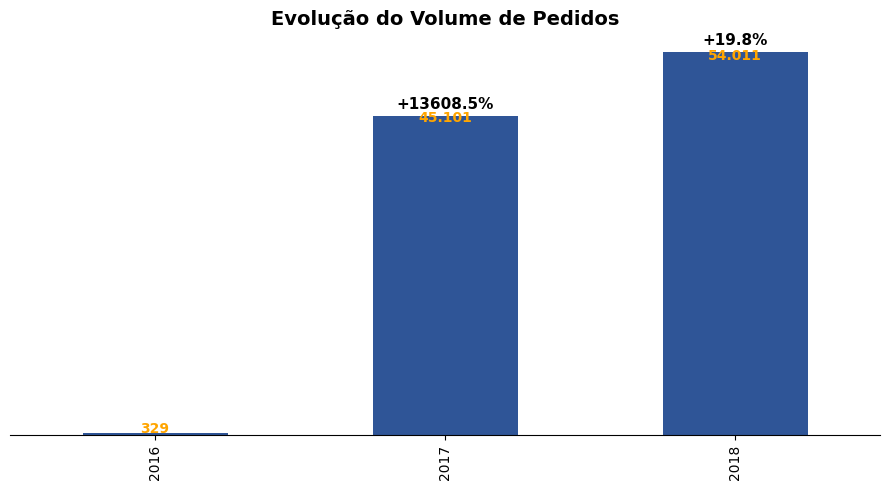

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

# =========================
# PEDIDOS POR ANO
# =========================
pedidos_ano = orders.groupby("ano")["order_id"].count().sort_index()

ax = pedidos_ano.plot(
    kind="bar",
    color="#2F5597"
)

plt.title("Evolução do Volume de Pedidos", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("")

# =========================
# REMOVER EIXO Y (VISUAL EXECUTIVO)
# =========================
ax.yaxis.set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# =========================
# CRESCIMENTO %
# =========================
valores = pedidos_ano.values

crescimento = [None]
for i in range(1, len(valores)):
    crescimento.append(((valores[i] - valores[i-1]) / valores[i-1]) * 100)

# =========================
# % DE CRESCIMENTO
# =========================
for i in range(1, len(valores)):
    plt.text(
        i,
        valores[i] * 1.02,
        f"+{crescimento[i]:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# =========================
# VALORES NAS BARRAS
# =========================
for i, v in enumerate(valores):
    plt.text(
        i,
        v * 0.98,
        f"{v:,}".replace(",", "."),
        ha="center",
        fontsize=10,
        color="orange",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()